# Modeling Non-Linear Patterns with Activation Functions

- A **linear model** can only learn straight-line patterns.
- Adding more linear neurons **without activation functions** still produces a linear model.
- **ReLU** introduces non-linearity.

## ReLU

ReLU works as:

- Negative input → `0`
- Positive input → unchanged

Each ReLU neuron can create a **bend** in the learned pattern.

**More ReLU neurons → more bends → more complex non-linear patterns.**


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
# Combined dataset: bikes for short distances, cars for longer ones
distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

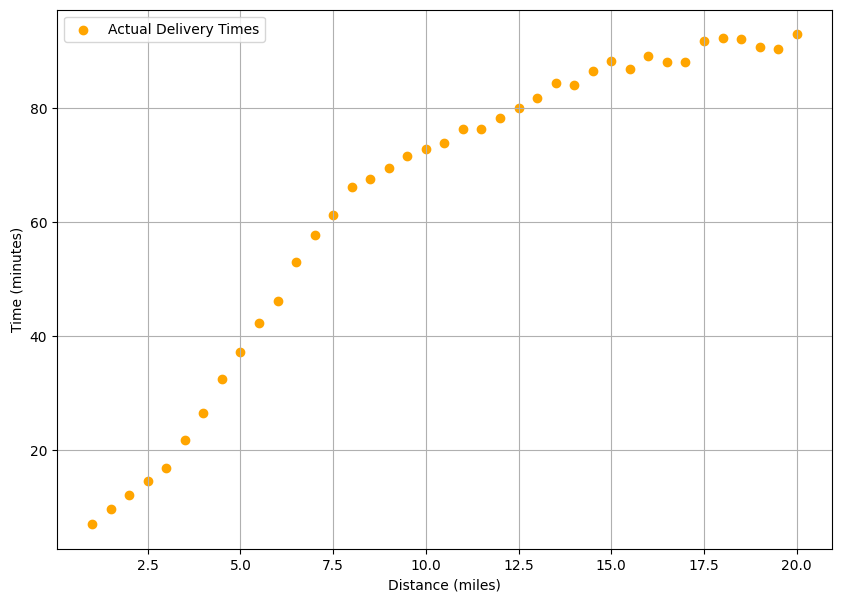

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    distances.numpy(),
    times.numpy(),
    color='orange',
    label='Actual Delivery Times'
)

plt.xlabel('Distance (miles)')
plt.ylabel('Time (minutes)')
plt.grid(True)
plt.legend()

plt.show()

# Normalizing the Data

**Standardization (Z-score normalization)** changes data to a common scale.

Formula:

$$
x_{norm} = \frac{x - \text{mean}}{\text{standard deviation}}
$$

For this dataset:

- Normalize `distances` using its mean and standard deviation.
- Normalize `times` using its mean and standard deviation.
- This helps **keep gradients stable** and makes training more effective.


In [5]:
# Calculate the mean and standard deviation for the 'distances' tensor
distances_mean = distances.mean()
distances_std = distances.std()

# Calculate the mean and standard deviation for the 'times' tensor
times_mean = times.mean()
times_std = times.std()

# Apply standardization to the distances.
distances_norm = (distances - distances_mean) / distances_std

# Apply standardization to the times.
times_norm = (times - times_mean) / times_std

## Effect of Normalization

- Normalization **changes the scale of the values**, not the pattern in the data.
- Before normalization:
  - Distance: `1 to 20 miles`
  - Time: approximately `7 to 93 minutes`
- After normalization:
  - Distance: approximately `-1.7 to 1.7`
  - Time: approximately `-2 to 1`
- The **curved relationship remains the same**.

**Same data pattern → different scale.**

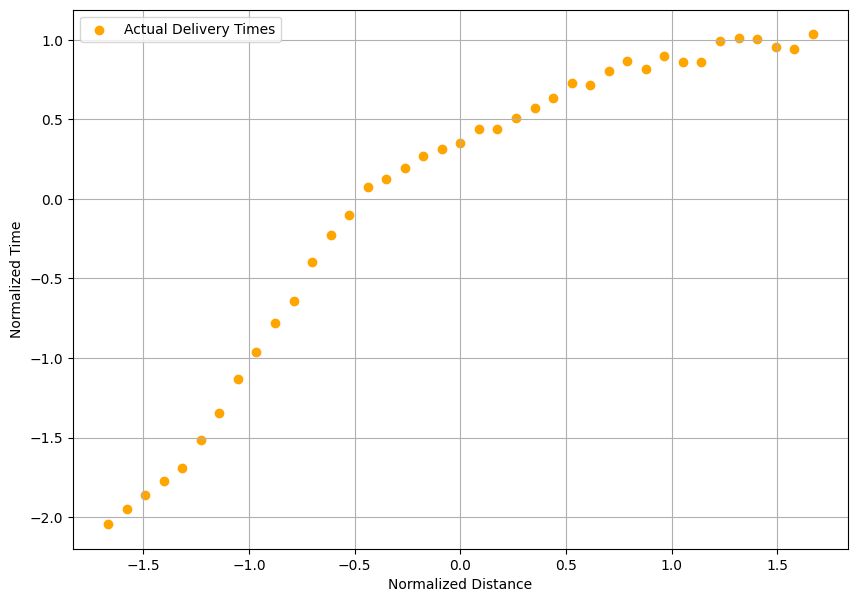

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    distances_norm.numpy(),
    times_norm.numpy(),
    color='orange',
    label='Actual Delivery Times'
)

plt.xlabel('Normalized Distance')
plt.ylabel('Normalized Time')
plt.grid(True)
plt.legend()

plt.show()

## Building the Non-Linear Model

* `nn.Linear(1, 3)`: This is your **first hidden layer**. It consists of three neurons, each receiving one input feature (the normalized distance). This layer transforms the single input value into three separate values.
* `nn.ReLU()` applies the ReLU activation function to the output of each of the three neurons from the hidden layer. This is the crucial non-linear step that allows your model to create "bends" and learn curves instead of just straight lines.
* `nn.Linear(3, 1)`: This is your **output layer**. It takes the three activated values from the previous step as its input and combines them to produce a single final output, which is your predicted (normalized) delivery time.

This creates a neural network with 1 hidden layer containing 3 neurons.

In [9]:
# This line ensures that your results are reproducible and consistent every time.
torch.manual_seed(27)

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)
# Define the loss function and optimizer
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Train the model

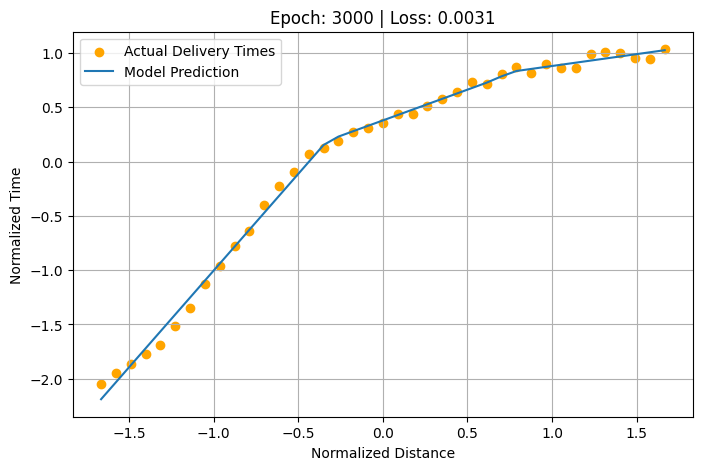

Training Complete.
Final Loss: 0.003143713343888521


In [10]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

for epoch in range(3000):

    optimizer.zero_grad()

    outputs = model(distances_norm)

    loss = loss_function(outputs, times_norm)

    loss.backward()

    optimizer.step()

    # Plot every 50 epochs
    if (epoch + 1) % 50 == 0:

        clear_output(wait=True)

        # Get current predictions
        with torch.no_grad():
            predictions = model(distances_norm)

        plt.figure(figsize=(8, 5))

        # Actual data
        plt.scatter(
            distances_norm.numpy(),
            times_norm.numpy(),
            color='orange',
            label='Actual Delivery Times'
        )

        # Model prediction
        plt.plot(
            distances_norm.numpy(),
            predictions.numpy(),
            label='Model Prediction'
        )

        plt.xlabel('Normalized Distance')
        plt.ylabel('Normalized Time')
        plt.title(f'Epoch: {epoch + 1} | Loss: {loss.item():.4f}')
        plt.grid()
        plt.legend()

        plt.show()

print("Training Complete.")
print(f"Final Loss: {loss.item()}")

## Checking the Final Fit 

Now that training is complete, we will visualize the result.


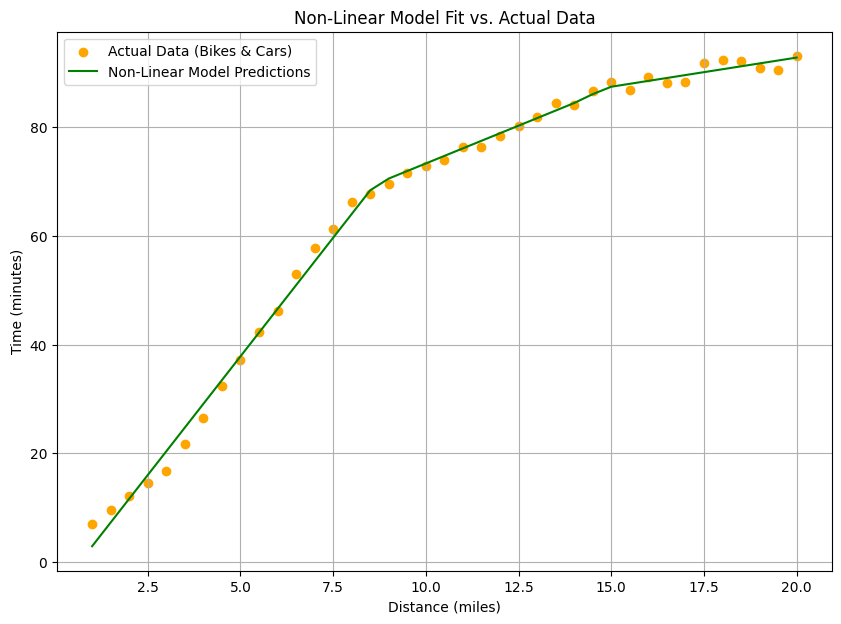

In [11]:
import matplotlib.pyplot as plt

# Model prediction using normalized distance
with torch.no_grad():
    predictions_norm = model(distances_norm)

# Convert normalized predictions back to minutes
predictions = predictions_norm * times_std + times_mean

plt.figure(figsize=(10, 7))

# Actual data
plt.scatter(
    distances.numpy(),
    times.numpy(),
    color='orange',
    label='Actual Data (Bikes & Cars)'
)

# Model prediction
plt.plot(
    distances.numpy(),
    predictions.numpy(),
    color='green',
    label='Non-Linear Model Predictions'
)

plt.xlabel('Distance (miles)')
plt.ylabel('Time (minutes)')
plt.title('Non-Linear Model Fit vs. Actual Data')

plt.grid()
plt.legend()
plt.show()

## Making a Prediction

With fully trained non-linear model, lets make a prediction for a new delivery. The process is slightly different now because  model was trained on *normalized* data.

* First, we will take the new input distance and **normalize** it using the same mean and standard deviation from training data. This step is CRITICAL: model has no idea about the original scales (miles and minutes). It only understands the normalized scale it was trained on.
* After the model provides its prediction, we must **de-normalize** the output. This converts the prediction from its normalized scale back into an understandable value in minutes.
* Finally, the code uses this actual predicted time to run the decision logic. For this prediction, assume the company now promises deliveries within 45 minutes and wants to know which vehicle to use.


In [12]:
distance_to_predict = 5.1
# Use the torch.no_grad() context manager for efficient prediction
with torch.no_grad():
    # Normalize the input distance
    distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)
    new_distance_norm = (distance_tensor - distances_mean) / distances_std
    
    # Get the normalized prediction from the model
    predicted_time_norm = model(new_distance_norm)
    
    # De-normalize the output to get the actual time in minutes
    predicted_time_actual = (predicted_time_norm * times_std) + times_mean
    
    # --- Decision Making Logic ---
    print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time_actual.item():.1f} minutes")
    
    # First, check if the delivery is possible within the 45-minute timeframe
    if predicted_time_actual.item() > 45:
        print("\nDecision: Do NOT promise the delivery in under 45 minutes.")
    else:
        # If it is possible, then determine the vehicle based on the distance
        if distance_to_predict <= 3:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (<= 3 miles), use a bike.")
        else:
            print(f"\nDecision: Yes, delivery is possible. Since the distance is {distance_to_predict} miles (> 3 miles), use a car.")

Prediction for a 5.1-mile delivery: 38.7 minutes

Decision: Yes, delivery is possible. Since the distance is 5.1 miles (> 3 miles), use a car.


# Conclusion

- A **linear model** can only learn straight-line patterns.
- Adding **ReLU** introduces non-linearity and allows the model to learn curved patterns.
- **More ReLU neurons → more possible bends → more complex patterns.**
- **Normalization** changes the scale of the data and helps make training more stable.
- New inputs must be **normalized** before prediction.
- Model outputs must be **de-normalized** to get the prediction in the original units.

### Key Idea

`Linear Layers + ReLU → Non-Linear Neural Network`

This allows neural networks to learn more complex real-world relationships.